# Introduction to machine learning

In this notebook we will summarize the most important topics and methods in machine learning and basic neuroscience

## Mathematical equipment: Statistics groundwork

### Probability density
Let $X$ be a random variable, with $x \in X$ continually distributed. The variable is described by a probability density $\rho (x)$. Therefore the probabilities are given by the integral:
$$
p(a < x < b) = \int_a^b \mathrm{d}x\,\, \rho(x)
$$
Moreover $\rho(x)$ is normalized with:
$$
\int_{-\infty}^{\infty}\mathrm{dx} \, \rho(x) = 1
$$
For discrete distributions one has to take the sum instead of the integral.

### Expectation value, mean, variance, standard deviation and n-th moment
Let $X$ be a random variable, we define:
\begin{align*}
    & \mu = E(X) = \int_{-\infty}^{\infty}\mathrm{dx} \, \rho(x) x && \textcolor{gray}{\text{expectation value}}\\
    & \braket{x} = \sum_{i=1}^N x_i /N && \textcolor{gray}{\text{mean}}\\
    & \sigma = \sqrt{\int \mathrm{d}x \, (x - \mu)^2\cdot \rho(x)} && \textcolor{gray}{\text{standard deviation}}\\
    & V(X) = (\sigma)^2 = E(X^2) - E(X)^2 && \textcolor{gray}{\text{variance}}\\
    & \mu_n = \braket{X^n} && \textcolor{gray}{\text{n-th moment}}\\
\end{align*}
Here again the integral holds for continuous distributions. The mean consists of the average of a number of $N$ measured events. The law of great numbers states that for $N \rightarrow \infty$ independent draws and finite $\mu$ (and variance) the mean is equal to the expectation value. 

### Conditional probability
The probability for $X = x_i$ under the condition $Y = y_j$ is given by:
$$
p(x_i | y_j) = \frac{p(x_i \land y_j)}{p(y_j)}
$$
where $p(x_i \land y_j)$ is the probability that $x_i$ **and** $y_j$ occur. In general $p(x_i | y_j) \neq p(y_j | x_i)$.
Moreover the following theorems hold:
$$
\begin{align*}
&p(x_i) = \sum_j p(x_i \land y_j)\\
&p(x_i \lor y_j) = p(x_i) + p(y_j) - p(x_i \land y_j)\\
&p(x_i | y_j) = \frac{p(y_j | x_i) \cdot p(x_i)}{p(y_j)} \qquad \quad \textcolor{gray}{\text{Bayes theorem}}
\end{align*}
$$

### Covariance and correlation
Consider the random variables $A,B$. The correlation function $\mathrm{Corr}(AB) \in [-1,1]$ tells us how strongly these two variables are correlated:
\begin{align*}
& \mathrm{Cov}(AB) = \braket{\left( A - \braket{A} \right) \left( B - \braket{B} \right)} = \braket{AB} - \braket{A}\braket{B} && \textcolor{gray}{\text{covariance}}\\
&\mathrm{Corr}(AB) = \frac{\braket{\left( A - \braket{A} \right) \left( B - \braket{B} \right)}}{\sigma_A \sigma_B} = \frac{\braket{AB} - \braket{A}\braket{B}}{\sigma_A \sigma_B} && \textcolor{gray}{\text{correlation}}
\end{align*}
For $\mathrm{Corr}(AB) = 0$ the variables are called uncorrelated. Independence ($\braket{A + B} = \braket{A} + \braket{B}$) implies zero correlation, but zero correlation does not in general imply independence. The covariance is a dimensionful measure of correlation.

The correlation matrix of a set of variables $x_1,\dots, x_N$ is a $N\times N$ matrix defined by its matrix elements (same for covariance matrix) 
$$
C_{ij} = \mathrm{Corr}(x_i,x_j)
$$
Note that diagonal elements are always 1, since a variable always correlates with itself. The information of interest is situated on the off-diagonals, showing relations between different variables.

#### Example
This can easily be implemented in python via numpy. Consider a matrix $m$ with house prices, in the first line of the matrix, and floor spaces in meter squared in the second line. We want to check if these two quantities are correlated:

In [1]:
import numpy as np

# define matrix m
m = np.array([
    [100, 250, 400, 500, 600, 900, 1500, 1550],
    [20, 45, 40, 50, 60, 54, 90, 120]
           ])

# we construct an expectation value function from scratch here (vector input)
def E(x):
    return np.sum(x) / len(x)

## covariance function with arrays as input
def covariance(x,y):
    return E(x*y) - E(x)*E(y)

## and also explicitly the cov matrix
def covariance_matrix(x, y):
    return np.array([
        [covariance(x,x), covariance(x,y)],
        [covariance(y,x), covariance(y,y)]
    ])
    
x=m[0]
y=m[1]

print('We calculated the covariance to be Cov(m) = Cov(x,y) = ')
print(covariance_matrix(x,y))

# now we compare with the numpy function
print('We compare with the result of numpy: Cov(m) = Cov(x,y) = ')
print(np.cov(x,y, bias=True))

We calculated the covariance to be Cov(m) = Cov(x,y) = 
[[262500.        14071.875   ]
 [ 14071.875       857.609375]]
We compare with the result of numpy: Cov(m) = Cov(x,y) = 
[[262500.        14071.875   ]
 [ 14071.875       857.609375]]


So in fact we see that the two parameters are highly correlated. Also one can unse "numpy.corrcoef" to get the normalized covariance matrix via the components:
$$
R_{ij} = \frac{C_{ij}}{\sqrt{C_{ii} C_{jj}}}
$$.

In [2]:
np.corrcoef(m)

array([[1.        , 0.93786981],
       [0.93786981, 1.        ]])


## Important probability distribution

### Binomial distribution
The binomial distribution is a discrete distribution. It describes the distribution of stochastic experiments for which we only have two possible outcomes.


Let $n$ be the number of draws. The probability to get $k$ as outcome, with respective probability $p$ is:
$$
B(k|n,p) = \binom{n}{k} p^k (1-p)^{n-k} = \frac{n!}{(n-k)! \,k!}\, p^k (1-p)^{n-k}
$$
Expectation value: $E(X) = np$\
Second moment: $E(X^2) = np + (n-1)p^2n$\
Variance: $\sigma = np(1-p)$


### Poisson distribution
The Poisson distribution $P_\mu$ is also a discrete probability density. It is described by the expectation value $\mu$:
$$P_\mu (k) = \frac{\mu^k}{k!}e^{-\mu}$$
Expectation value: $\mathrm{E}(X) = \mu$\
Second moment: $\mathrm{E}(X^2) = \mu^2 + \mu$\
Variance $\sigma = \mu$\
The Poisson distribution arises from the Binomial distribution for $n \rightarrow \infty$ and $p \rightarrow 0$ with $\mu = np$.

### Gaussian distribution
The Gaussian distribution arises from the Binomial for large $n$ and $\mu \gg \sigma$. And is the solution of the differential equation:
$$
\frac{\mathrm{d} \rho}{ \mathrm{d}k} = \rho(k) \cdot \left( - \frac{x}{\sigma}\right)
$$
and therefore with $k = \mu + \sigma x$
$$
\frac{\mathrm{d} \rho}{ \mathrm{d}x} = -x \cdot \rho(x) 
$$
This ODE leads to:
$$
\begin{align*}
\rho(x) &= c \cdot \mathrm{e}^{-x^2/2}\\
& = \frac{1}{\sigma \sqrt{2\pi}} \cdot \exp(-(\mu - k )^2 / 2\sigma^2)
\end{align*}
$$


## Estimation

Consider a sample $\mathbf{x} = \{x_1, x_2, \ldots, x_N\}$ drawn independently from a random variable $X$ with probability distribution $P(x)$. Suppose we want to estimate a property $\theta$ of the underlying distribution, such as the expectation value $\theta = E(X)$. The **estimator** $\hat{\theta}$ is a function of the random sample and is therefore itself a random variable. For example,
$$
\hat{\theta} = \frac{1}{N}\sum_{i=1}^N X_i
$$
is the estimator of the expectation value. Once a particular sample $\mathbf{x}$ has been observed, the estimator takes on a specific value,
$$
\hat{\theta}(\mathbf{x}) = \frac{1}{N}\sum_{i=1}^N x_i,
$$
which is called the **estimate**. Thus, $\theta$ is the fixed (but potentially unknown) population property, $\hat{\theta}$ is the random estimator, and $\hat{\theta}(\mathbf{x})$ is the resulting estimate for a particular sample.

## Properties of estimators
- **consistency:** $E(\hat\theta) \to \theta$ and $V(\hat\theta) \to 0$ for $N \to \infty$
- **bias:** $b := E(\hat\theta) - \theta$
- **effciency:** $\varepsilon := \frac{V_\mathrm{min}}{V(\hat\theta)}$ where $V_\mathrm{min}$ is the minimal possible variance 

## Likelihood

The easiest way to understand **likelihood** is to distinguish it from probability. Suppose a random variable depends on an unknown parameter $\theta$ (in example the mean $\mu$). If $\theta$ is known and we ask how likely an observation $x$ is, we consider the **probability**
$$
P(x\mid\theta).
$$

In parameter estimation, we have the opposite situation: a sample $\mathbf{x}$ has been measure, while $\theta$ is unknown. We therefore treat $\mathbf{x}$ as fixed and ask:

> **Which value of $\theta$ makes the observed data most plausible?**

This is the **likelihood**:
$$
L(\mathbf{x};\theta) = P(\mathbf{x}\mid\theta).
$$

The notation emphasizes that $\mathbf{x}$ is fixed while $\theta$ is varied. For independent observations, the probability of observing all of them together is the product and thus also
$$
L(\mathbf{x};\theta)
=
\prod_{i=1}^N P(x_i\mid\theta).
$$

The **maximum likelihood estimator (MLE)** is the parameter value that maximizes this likelihood:
$$
\hat{\theta}_{\mathrm{ML}}
=
\arg\max_\theta L(\mathbf{x};\theta).
$$


### Example: Gaussian measurements

Suppose we measure a quantity $N$ times and obtain $x_1,\ldots,x_N$, where measurement $i$ has uncertainty $\sigma_i$. Assuming Gaussian errors with unknown mean $\mu$,
$$
P(x_i\mid\mu)
=
\frac{1}{\sqrt{2\pi}\sigma_i}
\exp\left(
-\frac{(x_i-\mu)^2}{2\sigma_i^2}
\right).
$$
For independent measurements we get
$$
L(\mathbf{x};\mu)
=
\prod_{i=1}^N P(x_i\mid\mu).
$$
It is easier to maximize the logarithm of the likelihood:
$$
\log L(\mathbf{x};\mu)
=
-\frac12
\sum_{i=1}^N
\frac{(x_i-\mu)^2}{\sigma_i^2}
+\mathrm{const}.
$$
Maximizing this is equivalent to minimizing the weighted squared deviations. Setting the derivative to zero gives
$$
\hat{\mu}_{\mathrm{ML}}
=
\frac{\displaystyle\sum_i x_i/\sigma_i^2}
{\displaystyle\sum_i 1/\sigma_i^2}.
$$

Thus, the maximum likelihood estimate is an **uncertainty-weighted average**: measurements with smaller $\sigma_i$ receive more weight because they are more precise.

In one sentence:

> **Likelihood asks: given the data I observed, which parameter value would have made these data most plausible?**


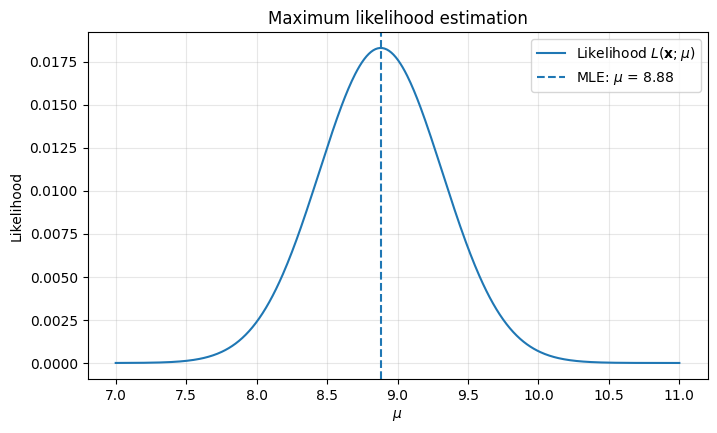

Maximum-likelihood estimate: mu = 8.88


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Observed measurements and their uncertainties
x = np.array([8.5, 10.0, 10.5])
sigma = np.array([0.5, 1.0, 2.0])
# We assume the data is Gauss distributed

# Try many possible values for the unknown mean
mu_values = np.linspace(7, 11, 500)

# Calculate the likelihood for each possible mu
likelihood = []

for mu in mu_values:
    # Probability of each measurement given this mu
    probabilities = (
        1 / (np.sqrt(2 * np.pi) * sigma)
        * np.exp(-(x - mu)**2 / (2 * sigma**2))
    )

    # Independent measurements -> multiply probabilities over x_i
    likelihood.append(np.prod(probabilities))

likelihood = np.array(likelihood)

# Find the maximum-likelihood estimate
mu_ml = mu_values[np.argmax(likelihood)]

# Plot likelihood as a function of mu
plt.figure(figsize=(8, 4.5))
plt.plot(mu_values, likelihood, label="Likelihood $L(\\mathbf{x};\\mu)$")
plt.axvline(mu_ml, linestyle="--",
            label=rf"MLE: $\mu$ = {mu_ml:.2f}")

plt.xlabel(r"$\mu$")
plt.ylabel("Likelihood")
plt.title("Maximum likelihood estimation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(rf"Maximum-likelihood estimate: mu = {mu_ml:.2f}")

## Implementation of Likelihood fit

We can use the Likelihood to fit a distribution to a dataset. The Likelihood Fit consists of the following steps:

- Choose a model $P(x\mid\theta)$ for how the data are distributed.
- Write the (log) likelihood for the observed data. 
- Maximize the likelihood (or log-likelihood) with respect to $\theta$. Note: when using scipy pass the negative log Likelihood, since scipy minimizes.
- The resulting $\hat{\theta}_{\mathrm{ML}}$ gives the fitted parameter values.

For multiple parameters, e.g. $\theta=(\theta_1,\theta_2)$, the same principle applies:
$$
\arg\max_{\theta_1,\theta_2}
L(\theta_1,\theta_2;\mathbf{x}).
$$
Note again here that in general one uses the logarithm of the Likelihood since products then become sums, which is easier to deal with.



### Example
Consider a sample $\mathbf{x} = \{x_1,x_2,\ldots,x_N\}$ drawn independently from a random variable $X$. We model the probability distribution with
$$
    P(x\mid\lambda_1,\lambda_2)
    =
    \frac{1}{2}\lambda_1 e^{-\lambda_1 x}
    +
    \frac{1}{2}\lambda_2 e^{-\lambda_2 x},
    \qquad x\geq 0,
$$
where the two parameters $\lambda_1>0$ and $\lambda_2>0$ are unknown. The likelihood of the observed sample is given by
$$
    L(\lambda_1,\lambda_2;\mathbf{x})
    =
    \prod_{i=1}^N
    P(x_i\mid\lambda_1,\lambda_2).
$$
It is more convenient to work with the log-likelihood,
$$
    \ell(\lambda_1,\lambda_2)
    =
    \log L(\lambda_1,\lambda_2;\mathbf{x}) = \sum_{i=1}^N
    \log
    \left(
    \frac{1}{2}\lambda_1 e^{-\lambda_1 x_i}
    +
    \frac{1}{2}\lambda_2 e^{-\lambda_2 x_i}
    \right).
$$
The maximum-likelihood estimates are obtained by maximizing the
log-likelihood with respect to both parameters,
$$
    (\hat{\lambda}_1,\hat{\lambda}_2)
    =
    \arg\max_{\lambda_1,\lambda_2}
    \ell(\lambda_1,\lambda_2).
$$
To find the maximum analytically, we set the derivatives of the
log-likelihood with respect to both parameters equal to zero.
For $\lambda_1$,
$$
    \frac{\partial\ell}{\partial\lambda_1}
    =
    \sum_{i=1}^N
    \frac{
    \frac{1}{2}e^{-\lambda_1x_i}
    \left(1-\lambda_1x_i\right)
    }{
    \frac{1}{2}\lambda_1e^{-\lambda_1x_i}
    +
    \frac{1}{2}\lambda_2e^{-\lambda_2x_i}
    }
    =0.
$$
Similarly, for $\lambda_2$,
$$
    \frac{\partial\ell}{\partial\lambda_2}
    =
    \sum_{i=1}^N
    \frac{
    \frac{1}{2}e^{-\lambda_2x_i}
    \left(1-\lambda_2x_i\right)
    }{
    \frac{1}{2}\lambda_1e^{-\lambda_1x_i}
    +
    \frac{1}{2}\lambda_2e^{-\lambda_2x_i}
    }
    =0.
$$
Unlike the single-exponential case, these two equations cannot in
general be solved explicitly for $\hat{\lambda}_1$ and
$\hat{\lambda}_2$. The maximum-likelihood estimates therefore have to
be determined numerically.
The fitted parameters are consequently given by
$$
    (\hat{\lambda}_1,\hat{\lambda}_2)
    =
    \arg\max_{\lambda_1>0,\lambda_2>0}
    \sum_{i=1}^N
    \log
    \left(
    \frac{1}{2}\lambda_1 e^{-\lambda_1 x_i}
    +
    \frac{1}{2}\lambda_2 e^{-\lambda_2 x_i}
    \right).
$$
Once the fitted parameters have been obtained, the fitted probability
distribution is
$$
    P(x\mid\hat{\lambda}_1,\hat{\lambda}_2)
    =
    \frac{1}{2}\hat{\lambda}_1
    e^{-\hat{\lambda}_1x}
    +
    \frac{1}{2}\hat{\lambda}_2
    e^{-\hat{\lambda}_2x}.
$$

The fitted distribution can then be compared with the observed data
using a histogram of the sample.

Note that the model is symmetric under the exchange
$
\lambda_1 \leftrightarrow \lambda_2.
$
Therefore, the parameter pairs
$
(\hat{\lambda}_1,\hat{\lambda}_2)
\,\text{and}\,
(\hat{\lambda}_2,\hat{\lambda}_1)
$
describe the same probability distribution.

True parameters:
lambda1 = 0.500
lambda2 = 2.000

Fitted parameters:
lambda1 = 0.481
lambda2 = 2.019


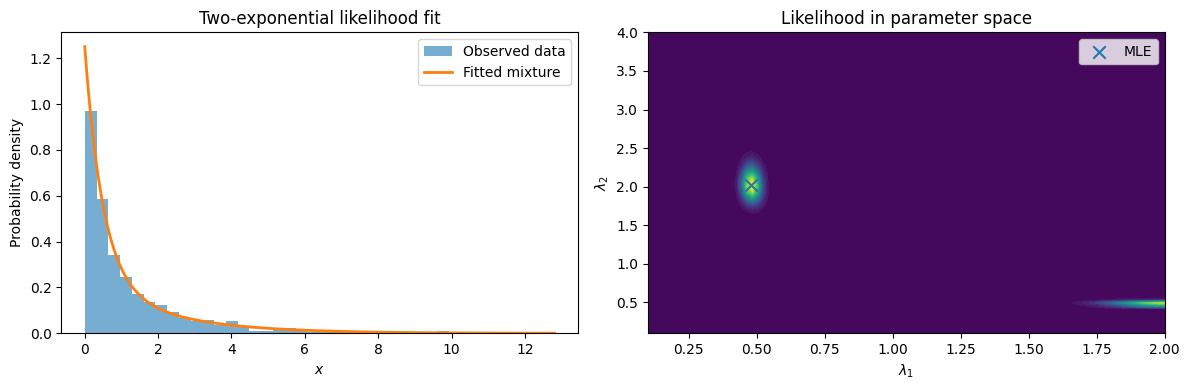

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ------------------------------------------------------------
# 1. Generate (recreatable) example data
# ------------------------------------------------------------
np.random.seed(42)
N = 1000
# True parameters
lambda1_true = 0.5
lambda2_true = 2.0

# Generate data from a 50/50 mixture of two exponential distributions
components = np.random.rand(N) < 0.5  # boolean list
x = np.where(
    components,
    np.random.exponential(1 / lambda1_true, N),
    np.random.exponential(1 / lambda2_true, N)
)


# ------------------------------------------------------------
# 2. Define the two-component exponential PDF 
# ------------------------------------------------------------
def pdf(x, lambda1, lambda2):
    return (
        0.5 * lambda1 * np.exp(-lambda1 * x)
        + 0.5 * lambda2 * np.exp(-lambda2 * x)
    )


# ------------------------------------------------------------
# 3. Define the negative log-likelihood
# ------------------------------------------------------------
def negative_log_likelihood(params):
    lambda1, lambda2 = params
    # Parameters must be positive
    if lambda1 <= 0 or lambda2 <= 0:
        return np.inf
    probabilities = pdf(x, lambda1, lambda2)
    # Numerical safety
    probabilities = np.maximum(probabilities, 1e-300)
    log_likelihood = np.sum(np.log(probabilities))
    # scipy minimizes, so return the negative log-likelihood
    return -log_likelihood


# ------------------------------------------------------------
# 4. Fit lambda1 and lambda2
# ------------------------------------------------------------
initial_guess = [0.4, 1.5]

result = minimize(
    negative_log_likelihood,
    initial_guess,
    method="Nelder-Mead"
)

lambda1_fit, lambda2_fit = result.x

print("True parameters:")
print(f"lambda1 = {lambda1_true:.3f}")
print(f"lambda2 = {lambda2_true:.3f}")

print("\nFitted parameters:")
print(f"lambda1 = {lambda1_fit:.3f}")
print(f"lambda2 = {lambda2_fit:.3f}")


# ------------------------------------------------------------
# 5. Calculate the fitted distribution
# ------------------------------------------------------------
x_plot = np.linspace(0, np.max(x), 1000)
y_fit = pdf(
    x_plot,
    lambda1_fit,
    lambda2_fit
)


# ------------------------------------------------------------
# 6. Plot the data and fitted distribution
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: data + fitted distribution ---
axes[0].hist(
    x,
    bins=40,
    density=True,
    alpha=0.6,
    label="Observed data"
)

axes[0].plot(
    x_plot,
    y_fit,
    linewidth=2,
    label="Fitted mixture"
)

axes[0].set_xlabel("$x$")
axes[0].set_ylabel("Probability density")
axes[0].set_title("Two-exponential likelihood fit")
axes[0].legend()


# ------------------------------------------------------------
# 7. Visualize the likelihood in parameter space
# ------------------------------------------------------------
lambda1_values = np.linspace(0.1, 2.0, 100)
lambda2_values = np.linspace(0.1, 4.0, 100)

L = np.zeros(
    (len(lambda2_values), len(lambda1_values))
)

for i, l1 in enumerate(lambda1_values):
    for j, l2 in enumerate(lambda2_values):

        probabilities = pdf(x, l1, l2)
        probabilities = np.maximum(probabilities, 1e-300)

        # Log-likelihood is used for numerical stability
        L[j, i] = np.sum(np.log(probabilities))

# Convert log-likelihood to a relative likelihood
L_relative = np.exp(L - np.max(L))

# Plot likelihood surface
im = axes[1].contourf(
    lambda1_values,
    lambda2_values,
    L_relative,   # We could also just use L for plotting but the relative value has more contrast (more visible maximum/minimum)
    levels=30
)

axes[1].scatter(
    lambda1_fit,
    lambda2_fit,
    s=80,
    marker="x",
    label="MLE"
)

axes[1].set_xlabel("$\\lambda_1$")
axes[1].set_ylabel("$\\lambda_2$")
axes[1].set_title("Likelihood in parameter space")
axes[1].legend()

plt.tight_layout()
plt.show()

## Chi-squared fits

An alternative fitting method is discussed in the following. The basic idea of a $\chi^2$ fit is very intuitive: Suppose we have measured values
$
y_1,y_2,\ldots,y_N
$
at known positions
$
x_1,x_2,\ldots,x_N,
$
and we have a model
$
f(x;\theta).
$
For a given parameter value $\theta$, the model predicts
$
f_i = f(x_i;\theta).
$
The difference between the observation and the model prediction is the **residual**
$$
r_i = y_i-f_i.
$$
If each measurement has an uncertainty $\sigma_i$, we can express the residual in units of its uncertainty:
$
\frac{y_i-f_i}{\sigma_i}.
$
The $\chi^2$ value is defined as
$$
\boxed{
\chi^2(\theta)
=
\sum_{i=1}^N
\frac{\left[y_i-f(x_i;\theta)\right]^2}{\sigma_i^2}
}
$$
Thus, $\chi^2$ measures how far the data are from the model, taking the uncertainties of the measurements into account, where large deviations are penalized strongly.
The best-fit parameters are obtained by minimizing $\chi^2$. In fact, under the assumption that the measurement errors are independent and Gaussian, minimizing $\chi^2$ is equivalent to maximizing the likelihood. 



### $\chi^2$ for histogram data

Suppose instead that we have a histogram with observed bin contents
$
O_1,O_2,\ldots,O_B.
$
Our model predicts an expected number of events in each bin,
$
E_1,E_2,\ldots,E_B.
$
A simple Pearson $\chi^2$ statistic is
$$
\boxed{
\chi^2
=
\sum_{i=1}^B
\frac{(O_i-E_i)^2}{E_i}
}
$$

where the denominator represents the expected variance for a Poisson
count when
$$
\operatorname{Var}(O_i)\approx E_i.
$$

More generally, if the uncertainty of a bin is $\sigma_i$, we can write

$$
\chi^2
=
\sum_{i=1}^B
\frac{(O_i-E_i)^2}{\sigma_i^2}.
$$

## Goodness of fit

After fitting a model we still want to know whether the fitted model provides a good description
of the observed data. This is a different question from finding the best-fit parameters.

- **Parameter estimation:** Which values of $\theta$ describe the data best?
- **Goodness of fit:** Is the resulting model actually compatible with the data?

There are several ways to quantify the goodness of a fit. The appropriate
method depends on the type of data and on what assumptions we are willing
to make.




### Reduced $\chi^2$

A commonly used quantity used for a measure of goodness is the **reduced chi-squared**
$$
\boxed{
\chi^2_\nu
=
\frac{\chi^2}{\nu},
}
$$
where $\nu$ is the number of degrees of freedom. If we have $N$ data points and fit $p$ independent parameters,
$$
\nu=N-p.
$$
Roughly speaking:

- $\chi^2_\nu\approx1$: the deviations are of the expected size.
- $\chi^2_\nu\gg1$: the data deviate from the model more than expected.
- $\chi^2_\nu\ll1$: the deviations are smaller than expected (errors to large, correlations in data or overfitting).

However, $\chi^2_\nu$ should not be interpreted as an absolute goodness-of-fit
measure by itself. Its interpretation depends on the uncertainty model,
the number of degrees of freedom, and the assumptions underlying the
$\chi^2$ statistic.


## Implementation of chi squared fit
TODO

# Minimization algorithm : Gradient descent optimization

Most deep learning algorithms involve optimization of some sort. Optimization
refers to the task of either minimizing or maximizing some function $f(x)$ by altering
$x$. We usually phrase most optimization problems in terms of minimizing $f(x)$. Maximization may be accomplished via a minimization algorithm by minimizing $-f(x)$. The function we want to minimize or maximize is called the objective function or criterion. When we are minimizing it, we may also call it the cost
function, loss function, or error function [Deep Learning Ian Goodfellow, S. 82].

We can decrease $f$ by moving in the direction of the negative gradient.
This is known as the method of steepest descent or gradient descent. A new point is then given by:
$$
x' = x - \eta \nabla_x f(x)
$$
where $\eta$ is the learning rate (step size) [Deep Learning Ian Goodfellow, S. 85,86].

# Machine learning algorithm: linear regression

Linear regression is a machine learning algorithm, that solves a regression prolem, where the input is connected linearly to the output. 

Consider an input matrix $\textbf{x} \in \mathbb{R}^{n\times p}$. The input consists of $p$ $\textbf{features}$ and each feature has $n$ input values. The output $\textbf{y} \in \mathbb{R}^p$ is then given by: 

$$
\textbf{y} = \textbf{x} \textbf{w} + \textbf{b}
$$
where $\textbf{w} \in \mathbb{R}^p$ is a vector of parameters and $\textbf{b}$ the bias or intercept. We can think of $\textbf{w}$ as a set of $\textbf{weights}$ that determine how each feature affects the output. If a feature receives a positive weight $w_i$, then increasing the value of that feature increases the value of our prediction $\hat{y}$. 

In a more sophisticate model one can absorb the bias in $\textbf{x}$ by adding a row of ones:
$$
\textbf{X} = \begin{pmatrix}
                1 & x_1^1 & \dots & x_1^p\\
                \vdots & \vdots & \ddots & \vdots\\
                1 & x_n^1 & \dots & x_n^p\\
             \end{pmatrix}
$$
If we define a new weight vector $\textbf{W} \in \mathbb{R}^{p+1}$, where $w_0$ corresponds to the bias, linear regression model becomes
$$
\textbf{y} = \textbf{X} \textbf{W}.
$$
Fitting a linear model to a given data set usually requires estimating the weights such that the error term $\textbf{E} = \textbf{y} − \textbf{X} \textbf{W}$ is minimized. For example, it is common to use the sum of squared errors 
$$
SSE = |\textbf{E}|^2 = |\textbf{y} − \textbf{X} \textbf{W}|^2
$$
as a measure of $\textbf{E}$ for minimization. 

## Implement linear regression for 1 feature

We consider the case where we only have one feature. We will persude the following steps:
- Compute linear regression using scikit-learn
- Examine the error curve 
- Compute linear regression "by hand" using pseudo matrix inverse
- Examine the error curve
- Compare both methods

In [18]:
#import packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#set plot specifications
def plot_secifications(xlabel, ylabel):
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

#define the data
def generate_data(true_slope):
    x = np.linspace(0,30,100)
    y = true_slope * x + np.random.randint(20, size=100)
    
    #reshape data
    x = x.reshape(-1,1)
    y = y.reshape(-1,1)
    return x,y

True Intercept: 0
Intercept: [9.79247525]
True Slope: 3.141592653589793
Slope: [3.10076097]


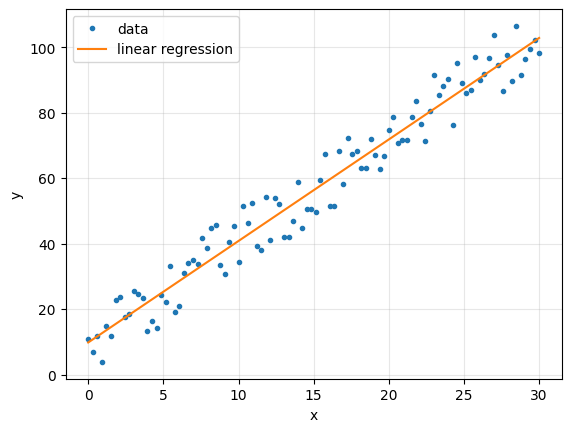

In [19]:
#generate data
true_slope = np.pi
x,y = generate_data(true_slope)

#create a LinearRegression object
lr = LinearRegression()

# fit the model to the data
lr.fit(x, y)

# print the intercept and slope of the fitted line
print('True Intercept:', 0)
print('Intercept:', lr.intercept_)
print('True Slope:', true_slope)
print('Slope:', lr.coef_[0])

#plot the data and fit
plt.plot(x, y, '.', label='data')
plt.plot(x, lr.coef_[0] * x + lr.intercept_, label='linear regression')
plot_secifications('x', 'y')

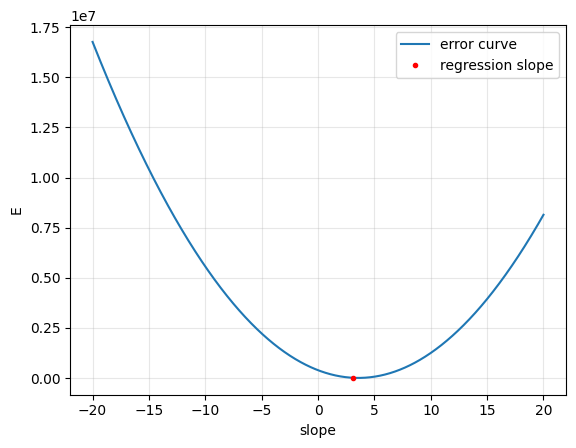

In [29]:
#examine error 
def E(x, y, slope_array):
    error = []
    for slope in slope_array:
        error.append(np.sum((y - x*slope)**2))
    return np.array(error)

def plot_error_curve():
    #print error curve
    slope_array = np.linspace(-20,20,1000)
    plt.plot(slope_array, E(x, y, slope_array), label='error curve')
    #plot the slope from linear regression
    plt.plot(lr.coef_[0], np.sum((y - x*lr.coef_[0])**2), '.', color='red', label='regression slope')
    plot_secifications('slope', 'E')
    
plot_error_curve()

We can see that the regression was sucessfull. The slope lies in the minimum of the error function, that we wanted to minimize.

We now perform the same steps using a by-hand minimization.

True Intercept: 0
Intercept: [9.73980198]
True Slope: 3.141592653589793
Slope: [3.08893919]


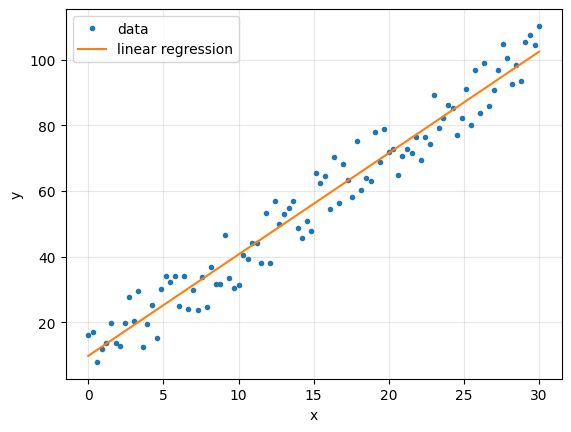

In [25]:
#generate data
true_slope = np.pi
x,y = generate_data(true_slope)

# add a column of ones to X for the intercept term
X_aug = np.hstack((np.ones((x.shape[0], 1)), x))

# compute the weights using the pseudo-inverse method
w = np.linalg.inv(X_aug.T.dot(X_aug)).dot(X_aug.T).dot(y)

# print the intercept and slope of the fitted line
print('True Intercept:', 0)
print('Intercept:', w[0])
print('True Slope:', true_slope)
print('Slope:', w[1])

#plot the data and fit
plt.plot(x, y, '.', label='data')
plt.plot(x, w[1] * x + w[0], label='linear regression')
plot_secifications('x', 'y')

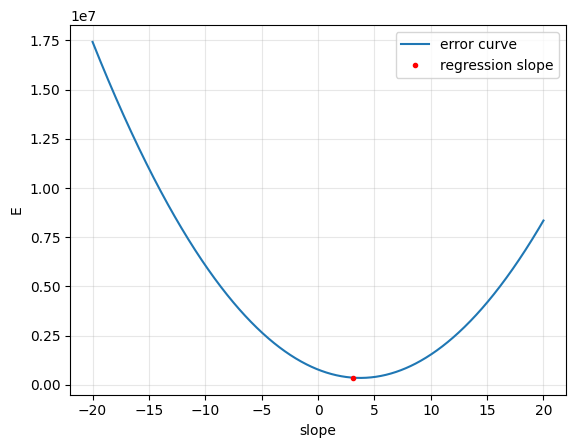

In [32]:
#examine error 
def E(x, y, slope_array):
    error = []
    for slope in slope_array:
        error.append(np.sum((y - x*slope)**2))
    return np.array(error)

def plot_error_curve():
    #print error curve
    slope_array = np.linspace(-20,20,1000)
    plt.plot(slope_array, E(X_aug, y, slope_array), label='error curve')
    #plot the slope from linear regression
    plt.plot(w[1], np.sum((y - w[1])**2), '.', color='red', label='regression slope')
    plot_secifications('slope', 'E')
    
plot_error_curve()

The difference between the two methods lies in the implementation details. Scikit-learn's LinearRegression uses the method of least squares, which is a common approach for solving linear regression problems. It involves setting up and solving a system of linear equations to obtain the optimal weights.

The pseudo-inverse method, on the other hand, is a matrix-based approach that involves computing the Moore-Penrose pseudo-inverse of the input matrix and using it to solve for the weights. This method is particularly useful when the input matrix is not full rank, meaning it does not have an inverse. In such cases, the pseudo-inverse provides a way to obtain a solution that minimizes the sum of squared errors.

Both methods will produce the same result for a given linear regression problem, but the pseudo-inverse method can be more computationally efficient in some cases, particularly when the input matrix is not full rank. Scikit-learn's LinearRegression is a more general method that can be applied to a variety of linear regression problems, and it also includes additional features such as regularization options and methods for handling categorical variables [chatGPT].

# Digit recognition with MNIST

In the following we implement a digit recognition (machine learning) algorithm taken from https://github.com/salah3x/nn-and-dl/blob/master/network.py.

In the following we use the stochastic gradient descent learning
algorithm for a feedforward neural network.  Gradients are calculated
using backpropagation.  